Answers for Week 6

* Name: Sophie Leszek
* Username: zeleszek
* Student s-number: s5686709
* Group (AS1, etc.): AS5

In [2]:
from astropy.io import fits
from scipy import stats
import numpy as np
from matplotlib import pyplot as plt

Filename: m101.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     125   (530, 530)   int16   
  1  Photometric CALTABLE    1 BinTableHDU     39   16R x 4C   [1D, 1D, 1D, 1J]   

SIMPLE  =                    T /FITS header                                     BITPIX  =                   16 /No.Bits per pixel                               NAXIS   =                    2 /No.dimensions                                   NAXIS1  =                  530 /Length X axis                                   NAXIS2  =                  530 /Length Y axis                                   END                                                                                                                                                                                                                                                                                                                                                                               

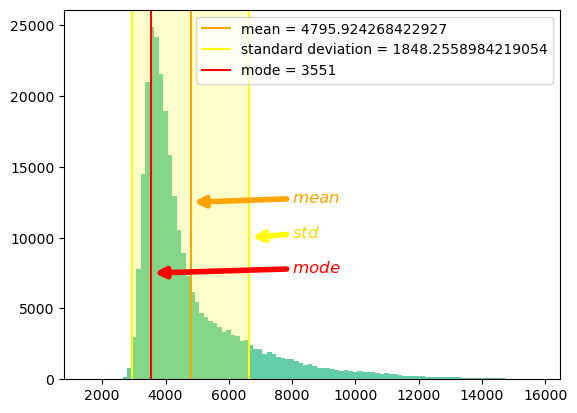

In [81]:
#6.1

hdulist = fits.open('m101.fits')
hdulist.info()

#there's 2 HDUs
#the first (primary) header contains image data
#number type: int16
print()

keys = hdulist[0].header  #keywords
print(keys[:5])

#BITPIX = 16, coresponds to the nr type

dat = hdulist[0].data
print()
print(dat.shape) 
print(dat.dtype) 

#the shape us (530, 530)
#corresponds to the dimensions from info() and values from NAXIS
#from .dtype: >i2

#.dtype (data type) defines how bytes in memory are interpreted, 
#specifying the type (e.g., int, float, bool), size, 
#and byte order of array elements

#corresponds to BITPIX=16 cuz 2bytes=16bits

flatdat = dat.flatten()
nobs, (minval, maxval), mean, var, skew, kurt = stats.describe(flatdat)
mode, counts = stats.mode(dat.flat)
print()
print(f"minimum = {minval}, maximum = {maxval}, mean = {mean},std = {var**0.5}, median = {np.median(flatdat)}, mode = {mode}")

#histogram

plt.hist(flatdat, bins=100, color='mediumaquamarine')
plt.axvline(mean, color = 'orange', label = f"mean = {mean}")
plt.axvline(mean - var**0.5, color = 'yellow', label = f"standard deviation = {var**0.5}")
plt.axvline(mean + var**0.5, color = 'yellow')
plt.axvspan(mean - var**0.5, mean + var**0.5, color='yellow', alpha=0.2) #shading
plt.axvline(mode, color = 'red', label = f"mode = {mode}")
plt.legend()
plt.annotate(r"$mean$",
             xy=(4795.9, 12500),       
             xytext=(8000, 12500),               # text position
             arrowprops=dict(color='orange', arrowstyle='-|>', linewidth=4, mutation_scale=15),
             color='orange', fontsize=12)
plt.annotate(r"$std$",
             xy=(6645, 10000),       
             xytext=(8000, 10000),               # text position
             arrowprops=dict(color='yellow', arrowstyle='-|>', linewidth=4, mutation_scale=15),
             color='gold', fontsize=12)
plt.annotate(r"$mode$",
             xy=(3551, 7500),       
             xytext=(8000, 7500),               # text position
             arrowprops=dict(color='red', arrowstyle='-|>', linewidth=4, mutation_scale=15),
             color='red', fontsize=12)
plt.show()


hdulist[0].header['BUNIT'] = 'Counts'

floatdat = dat.astype(float)

hdulistout = fits.PrimaryHDU(floatdat)
hdulistout.header = keys
hdulistout.writeto('floatfits.fits', overwrite=True, output_verify='ignore')
hdulist.close()

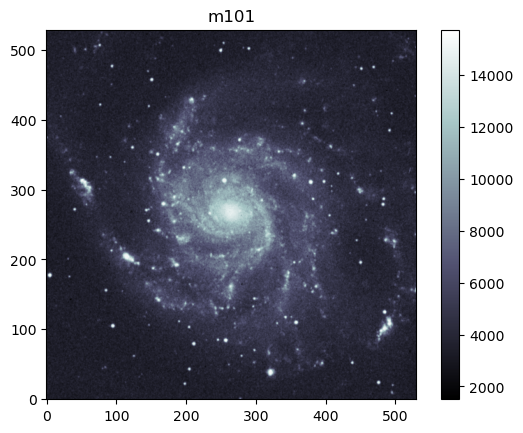

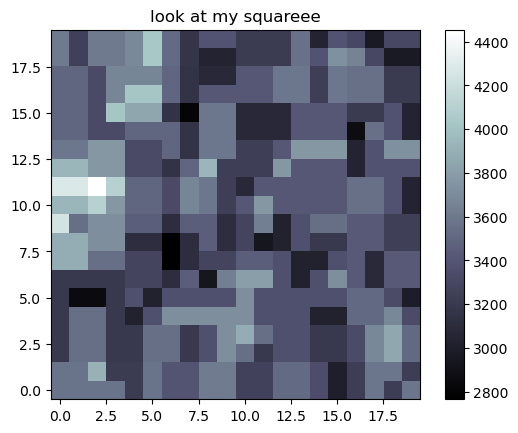

rms of the square: 60.79673099764493
mean of the square: 3422.8825, std: 260.1300322795313


In [80]:
#6.3
#the actual image:
plt.imshow(dat, cmap='bone', origin='lower')
plt.colorbar()
plt.title("m101")
plt.show()

square = dat[0:20, 0:20] #selected region
#look at the square:
plt.imshow(square, cmap='bone', origin='lower')
plt.colorbar()
plt.title("look at my squareee")
plt.show()

#RMS
rms = np.sqrt(np.mean(square**2))
print(f"rms of the square:", rms)

#mean, std:
m = np.mean(square)
s = np.std(square)
print(f"mean of the square: {m}, std: {s}")
#std seems like a better estimate, cuz rms can be skewed by the overall brightness of the image

In [95]:
#6.5
#reading the data:
hdulist0 = fits.open('noisemap0.fits')
hdulist1 = fits.open('noisemap1.fits')
hdulist2 = fits.open('noisemap2.fits')

hdu0 = hdulist0[0].header
hdu1 = hdulist1[0].header
hdu2 = hdulist2[0].header

dat0 = hdulist0[0].data
dat1 = hdulist1[0].data
dat2 = hdulist2[0].data

flatdat0 = dat0.flatten()
flatdat1 = dat1.flatten()
flatdat2 = dat2.flatten()

nobs0, (minval0, maxval0), mean0, var0, skew0, kurt0 = stats.describe(flatdat0)
mode0, counts0 = stats.mode(dat0.flat)

nobs1, (minval1, maxval1), mean1, var1, skew1, kurt1 = stats.describe(flatdat1)
mode1, counts1 = stats.mode(dat1.flat)

nobs2, (minval2, maxval2), mean2, var2, skew2, kurt2 = stats.describe(flatdat2)
mode2, counts2 = stats.mode(dat2.flat)

#stds:
std0 = var0**0.5
std1 = var1**0.5
std2 = var2**0.5

#stacking:
imgs = [dat0, dat1, dat2]
stacked = np.stack(imgs)

#mean:
mean_image = np.mean(stacked, axis=0)

#mean std:
nobs_s, (minval_s, maxval_s), mean_s, var_s, skew_s, kurt_s = stats.describe(mean_image.flatten())
std_s = var_s**0.5

#calculated std:
std_calc = (1/3) * (std0**2 + std1**2 + std2**2)**0.5

print(f"std of the stacked image: {std_s}, calculated std: {std_calc}")
print(f"std_s = std_calc:", std_s == std_calc)
print(f"but its close")

std of the stacked image: 5.77319500814915, calculated std: 5.7702982094616235
std_s = std_calc: False
but its close


In [17]:
#6.6
# Open the FITS file
hdul = fits.open('APOGEE_stars.fits')

# Access the primary data (in this case, it is a Table)
data = hdul[1].data  # Often, the first extension contains the table
colnames = hdul[1].columns.names # List of the column names
print(data)
print()
print(colnames)

#An image is a 2D array of pixel values
#a table is a structured dataset where each row 
#represents an object and each column represents a property

#Conditions:
#inside brackets: conditions specified for DATAFLAG==1
#& used so that all conditions have to be satisfied simultaneously (is this spelling right?)
#which, that's a boolean array
conditions = (
    (data['STARFLAG'] == 0) &
    (data['ASPCAPFLAG'] == 0) &
    (data['SNR'] > 10) &
    (data['GAIAEDR3_PARALLAX'] / data['GAIAEDR3_PARALLAX_ERROR'] > 5) &
    (~np.isnan(data['GAIAEDR3_PHOT_G_MEAN_MAG'])) &
    (~np.isnan(data['GAIAEDR3_PHOT_BP_MEAN_MAG'])) &
    (~np.isnan(data['GAIAEDR3_PHOT_RP_MEAN_MAG']))
) 

dataflag = conditions.astype(int) #so that True->1 False->0

#adding DATAFLAG to the collumns
columns = data.columns + fits.Column(name='DATAFLAG', array=dataflag, format='I') #the addition being DATAFLAG, I being integer
hdu = fits.BinTableHDU.from_columns(columns)

print()


px = data['GAIAEDR3_PARALLAX']  #parallax
m = data['GAIAEDR3_PHOT_G_MEAN_MAG'] #magnitude in G

M = m + 5 * np.log10(px / 1000) + 5 #absolute magnitude in G

abs_mag = np.where(
    dataflag == 1, #the condition
    M, #result if true
    -1.0 #result if false
)

columns = hdu.columns + fits.Column(name='GAIAEDR3_ABS_MAG', array=abs_mag, format='E')
hdu = fits.BinTableHDU.from_columns(columns)
print(hdu.columns.names)

#saving the updated file:

hdul_upd = fits.HDUList([
    fits.PrimaryHDU(),  # empty primary HDU
    hdu                 # the new table
])

hdul_upd.writeto('APOGEE_update.fits', overwrite=True)

[(       nan,       nan,     nan,     nan,     nan, 133,    0, 418.9276  )
 (0.28544167, 0.019475 , 11.6988, 13.2722, 10.4956,   0, 3072, 827.1565  )
 (0.08209286, 0.315081 , 12.2882, 12.5149, 11.6597,  68,    0, 229.87506 )
 ...
 (0.33459017, 0.0153441, 13.9818, 14.7112, 13.1544,   0, 2052, 130.77075 )
 (0.01822683, 0.0693144, 17.5628, 18.1846, 16.8085,   0,    0,  33.586742)
 (2.0103858 , 0.0225479, 11.6622, 11.9146, 11.2472,  64,  516, 209.74567 )]

['GAIAEDR3_PARALLAX', 'GAIAEDR3_PARALLAX_ERROR', 'GAIAEDR3_PHOT_G_MEAN_MAG', 'GAIAEDR3_PHOT_BP_MEAN_MAG', 'GAIAEDR3_PHOT_RP_MEAN_MAG', 'ASPCAPFLAG', 'STARFLAG', 'SNR']

['GAIAEDR3_PARALLAX', 'GAIAEDR3_PARALLAX_ERROR', 'GAIAEDR3_PHOT_G_MEAN_MAG', 'GAIAEDR3_PHOT_BP_MEAN_MAG', 'GAIAEDR3_PHOT_RP_MEAN_MAG', 'ASPCAPFLAG', 'STARFLAG', 'SNR', 'DATAFLAG', 'GAIAEDR3_ABS_MAG']


/tmp/ipykernel_1627359/116671329.py:42: RuntimeWarning: invalid value encountered in log10
  M = m + 5 * np.log10(px / 1000) + 5 #absolute magnitude in G


In [5]:
#6.7


In [6]:
#6.10

In [7]:
#6.14